<a href="https://colab.research.google.com/github/Raffy0-1/Sign-language-to-Speech/blob/main/sign_language_to_speech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sign Language to Live Speech

This notebook builds a full pipeline that reads hand gestures from a webcam and speaks them out loud.

We start with ASL (American Sign Language) data because a large public dataset exists for it. Once the pipeline is validated and working, you swap in your own PSL (Pakistani Sign Language) recordings — the architecture does not change at all. Only the data changes.

---

## Why not YOLOv11 for this?

YOLO is an object detector. It looks at a single image and finds objects in it spatially. That works well for detecting whether a hand is open or closed in one frozen frame.

But sign language words are expressed through motion over time — the way a hand moves from position A to position B is what gives a sign its meaning. To understand that, your model needs to process a sequence of frames, not a single frame.

An LSTM (Long Short-Term Memory network) is built exactly for this. It processes a sequence one step at a time and remembers what happened earlier in the sequence when making a decision at the end. Think of it as reading a sentence word by word and understanding the full meaning only at the end, rather than reading a single word in isolation.

So the architecture is:
- MediaPipe extracts 21 hand landmark points from every frame (63 numbers per frame: x, y, z for each joint)
- We collect 30 consecutive frames to form one sequence (one sign)
- The LSTM reads those 30 frames in order and outputs a class label (which word was signed)
- gTTS converts that word to speech

---

## Notebook structure

1. Mount Google Drive and set up folder structure
2. Install dependencies
3. Understand what MediaPipe gives us
4. Collect training data (record landmark sequences per sign)
5. Build and understand the LSTM model
6. Train and save the model to Drive
7. Evaluate with a confusion matrix
8. Run the real-time demo with webcam + speech output


## Section 1 — Mount Google Drive

Everything we produce — collected data, trained model weights, label maps — gets saved to your Google Drive. This means if your Colab session expires, you reconnect, mount Drive, and continue from exactly where you left off. No retraining, no data loss.

In [13]:
from google.colab import drive

# This will open a popup asking you to authenticate with your Google account.
# After that, your Drive is accessible at /content/drive/MyDrive/
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os

# All project files live inside this one folder on your Drive.
# Change PROJECT_ROOT if you want a different location.
PROJECT_ROOT = '/content/drive/MyDrive/sign_language_project'

# Sub-folders we will use throughout the notebook
DATA_DIR   = os.path.join(PROJECT_ROOT, 'data')        # landmark sequences go here
MODEL_DIR  = os.path.join(PROJECT_ROOT, 'models')      # saved model weights
LOG_DIR    = os.path.join(PROJECT_ROOT, 'logs')        # training logs

# Create all folders if they do not exist yet.
# exist_ok=True means this cell is safe to re-run — it will not throw an error
# if the folders are already there.
for folder in [PROJECT_ROOT, DATA_DIR, MODEL_DIR, LOG_DIR]:
    os.makedirs(folder, exist_ok=True)

print('Drive mounted and project folders ready.')
print(f'Project root: {PROJECT_ROOT}')

Drive mounted and project folders ready.
Project root: /content/drive/MyDrive/sign_language_project


## Section 2 — Install dependencies

We install specific versions here to avoid compatibility issues with Colab's environment.

- `mediapipe` — Google's library for detecting and tracking hand landmarks in real time
- `gtts` — Google Text-to-Speech, converts a string to an MP3 audio file
- `tensorflow` — the deep learning framework we use to build and train the LSTM
- `scikit-learn` — for splitting data and computing evaluation metrics
- `matplotlib` / `seaborn` — for plotting the confusion matrix and training curves

The `--quiet` flag just suppresses the wall of installation text so the output stays readable.

In [15]:
!pip install mediapipe --quiet
!pip install gtts --quiet

print('mediapipe and gtts installed.')
print('TensorFlow, NumPy, OpenCV, scikit-learn, matplotlib, seaborn are pre-installed on Colab.')

mediapipe and gtts installed.
TensorFlow, NumPy, OpenCV, scikit-learn, matplotlib, seaborn are pre-installed on Colab.


In [16]:
# Standard library
import os
import time
import json
import base64

# Numerical computing — pre-installed on Colab
import numpy as np

# Computer vision — pre-installed on Colab
import cv2

# MediaPipe — just installed above
import mediapipe as mp

# TensorFlow / Keras — pre-installed on Colab
# We import from tensorflow.keras rather than standalone keras to stay
# compatible with however Colab has it configured.
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
from tensorflow.keras.utils import to_categorical

# Data splitting and evaluation — pre-installed on Colab
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Visualization — pre-installed on Colab
import matplotlib.pyplot as plt
import seaborn as sns

# Colab utilities
from IPython.display import Audio, display, Javascript
from google.colab import files

# gTTS — just installed above
from gtts import gTTS

# Print versions so you know exactly what environment you are running in.
# If there is ever a compatibility issue in the future, these numbers tell you where to look.
print(f'Python:     {__import__("sys").version.split()[0]}')
print(f'TensorFlow: {tf.__version__}')
print(f'MediaPipe:  {mp.__version__}')
print(f'NumPy:      {np.__version__}')
print(f'OpenCV:     {cv2.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

Python:     3.12.13
TensorFlow: 2.20.0
MediaPipe:  0.10.35
NumPy:      2.0.2
OpenCV:     4.13.0
GPU available: True


## Section 3 — Understanding what MediaPipe gives us

Before collecting data, it helps to understand exactly what the input to our model looks like.

MediaPipe Hands detects 21 landmarks on each hand. Each landmark is a point in 3D space described by three numbers: x, y, and z.

- x and y are the pixel coordinates of the joint, normalized to a 0–1 range relative to the image width and height
- z is the estimated depth — how far the landmark is from the camera. It is also normalized and is less accurate than x and y, but still useful

21 landmarks times 3 values each = 63 numbers per frame per hand.

The 21 landmarks correspond to specific joints: wrist, thumb base through tip, index finger base through tip, and so on. MediaPipe always returns them in the same order so the model learns which position in the array means which joint.

We also normalize all coordinates relative to the wrist landmark. This makes the representation independent of where the hand appears in the frame — whether you hold your hand in the top left or bottom right of the camera view, the feature vector looks the same.

In [17]:
import urllib.request

# The new MediaPipe Tasks API requires a separate model file download.
# The model file contains the trained weights for hand landmark detection.
# We download it once and save it to Drive so future sessions skip this step.

MODEL_PATH = os.path.join(PROJECT_ROOT, 'hand_landmarker.task')

if not os.path.exists(MODEL_PATH):
    print('Downloading hand landmarker model...')
    url = 'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task'
    urllib.request.urlretrieve(url, MODEL_PATH)
    print(f'Model saved to Drive: {MODEL_PATH}')
else:
    print('Hand landmarker model already on Drive. Skipping download.')

# Import the specific classes we need from the new Tasks API.
# In the old API you did: mp.solutions.hands.Hands()
# In the new API you do:  mp.tasks.vision.HandLandmarker.create_from_options(options)
BaseOptions         = mp.tasks.BaseOptions
HandLandmarker      = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode   = mp.tasks.vision.RunningMode

# Landmark names for reference — same 21 joints as before, same order.
LANDMARK_NAMES = [
    'WRIST',
    'THUMB_CMC', 'THUMB_MCP', 'THUMB_IP', 'THUMB_TIP',
    'INDEX_FINGER_MCP', 'INDEX_FINGER_PIP', 'INDEX_FINGER_DIP', 'INDEX_FINGER_TIP',
    'MIDDLE_FINGER_MCP', 'MIDDLE_FINGER_PIP', 'MIDDLE_FINGER_DIP', 'MIDDLE_FINGER_TIP',
    'RING_FINGER_MCP', 'RING_FINGER_PIP', 'RING_FINGER_DIP', 'RING_FINGER_TIP',
    'PINKY_MCP', 'PINKY_PIP', 'PINKY_DIP', 'PINKY_TIP'
]

print(f'Total landmarks: {len(LANDMARK_NAMES)}')
print(f'Values per frame: {len(LANDMARK_NAMES) * 3}  (x, y, z per landmark)')

Hand landmarker model already on Drive. Skipping download.
Total landmarks: 21
Values per frame: 63  (x, y, z per landmark)


In [18]:
def extract_landmarks(detection_result):
    """
    Takes the output from the new HandLandmarker API and returns a flat
    numpy array of 63 numbers, normalized relative to the wrist.

    The new API returns a HandLandmarkerResult object. The landmarks live at:
        detection_result.hand_landmarks  -> list of hands
        detection_result.hand_landmarks[0]  -> list of 21 NormalizedLandmark objects
        detection_result.hand_landmarks[0][i].x / .y / .z  -> coordinates

    Everything else — normalization, flattening — is identical to before.

    Args:
        detection_result: HandLandmarkerResult from landmarker.detect() or detect_for_video()

    Returns:
        numpy array of shape (63,)
    """
    if not detection_result.hand_landmarks:
        return np.zeros(63)

    # Take the first detected hand
    hand = detection_result.hand_landmarks[0]

    # Build array of shape (21, 3)
    raw = np.array([[lm.x, lm.y, lm.z] for lm in hand])

    # Normalize relative to wrist (landmark 0)
    wrist = raw[0]
    normalized = raw - wrist

    return normalized.flatten()


print('extract_landmarks function defined.')
print('Output shape per frame: (63,)')

extract_landmarks function defined.
Output shape per frame: (63,)


## Section 4 — Download and preprocess the WLASL dataset

Instead of recording your own signs, we use the WLASL (Word-Level American Sign Language) dataset.
It contains around 12,000 video clips of 2,000 ASL words, each recorded by multiple signers.
We use the top 10 most common words from WLASL100 to keep training fast on free Colab.

**What this section does:**
1. Connects to Kaggle and downloads the dataset (you need a free Kaggle account)
2. Reads the WLASL annotation JSON which tells us which video belongs to which word
   and which frames within that video contain the actual sign
3. For each video, samples exactly 30 frames evenly spaced between the start and end frame
4. Runs each frame through MediaPipe to extract 63 landmark values
5. Saves the resulting (30, 63) array to Drive

**Why evenly-spaced sampling instead of taking the first 30 frames:**
Different people sign at different speeds. One video of 'hello' might be 20 frames, another 60.
If we just took the first 30 frames of a 60-frame video we would only capture half the sign.
Evenly-spaced sampling stretches or compresses every sign to exactly 30 steps,
so the model always sees the full motion regardless of how fast the signer was.

**Kaggle API setup (do this once):**
1. Go to kaggle.com and log in
2. Click your profile picture -> Settings -> API -> Create New Token
3. This downloads a file called `kaggle.json`
4. Upload that file when the next cell asks for it


In [19]:
import os
from google.colab import files
import shutil # Import the shutil module

# Check if kaggle.json is already saved on Drive from a previous session.
# If yes, we copy it to the location the Kaggle CLI expects and skip the upload.
kaggle_creds_on_drive = os.path.join(PROJECT_ROOT, 'kaggle.json')
kaggle_target = os.path.expanduser('~/.kaggle/kaggle.json')

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

if os.path.exists(kaggle_creds_on_drive):
    # Already saved from a previous session — just copy it into place
    shutil.copy(kaggle_creds_on_drive, kaggle_target)
    os.chmod(kaggle_target, 0o600)  # Kaggle CLI requires restricted permissions
    print('Kaggle credentials loaded from Drive. No upload needed.')
else:
    # First time — ask the user to upload kaggle.json
    print('Please upload your kaggle.json file.')
    print('Get it from: kaggle.com -> Profile -> Settings -> API -> Create New Token')
    uploaded = files.upload()

    uploaded_kaggle_key = None
    for key in uploaded.keys():
        if key.startswith('kaggle') and key.endswith('.json'):
            uploaded_kaggle_key = key
            break

    if uploaded_kaggle_key is None:
        raise ValueError('Upload cancelled or wrong file. Please upload kaggle.json')

    # Write the uploaded file to the expected location as 'kaggle.json'
    with open(kaggle_target, 'wb') as f:
        f.write(uploaded[uploaded_kaggle_key])
    os.chmod(kaggle_target, 0o600)

    # Also save a copy to Drive so future sessions skip the upload
    shutil.copy(kaggle_target, kaggle_creds_on_drive)
    print('Kaggle credentials saved to Drive for future sessions.')

Kaggle credentials loaded from Drive. No upload needed.


In [20]:
import zipfile

# Where the raw downloaded videos will live (inside Colab's local storage, not Drive).
# We keep the raw videos local because they are large and we only need them during preprocessing.
# What goes to Drive is the extracted landmark sequences, which are tiny by comparison.
VIDEOS_DIR = '/content/wlasl_videos'
ZIP_PATH   = '/content/wlasl-processed.zip'

# Only download if we have not done so already in this session
if not os.path.exists(VIDEOS_DIR):
    print('Downloading WLASL dataset from Kaggle...')
    print('This is around 1.5 GB and may take 5-10 minutes on Colab.')

    # The Kaggle CLI downloads and saves to the current directory by default.
    # We redirect to /content to keep things tidy.
    !kaggle datasets download -d risangbaskoro/wlasl-processed -p /content --quiet

    print('Download complete. Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(VIDEOS_DIR)

    # Remove the zip to free up disk space — Colab's local disk is limited to ~80 GB
    os.remove(ZIP_PATH)
    print(f'Extracted to {VIDEOS_DIR}')
else:
    print('Dataset already downloaded in this session. Skipping.')

# List what we got
contents = os.listdir(VIDEOS_DIR)
print(f'Files in dataset folder: {len(contents)}')
print(f'Sample entries: {contents[:5]}')

This is around 1.5 GB and may take 5-10 minutes on Colab.
Dataset URL: https://www.kaggle.com/datasets/risangbaskoro/wlasl-processed
License(s): other
Download complete. Extracting...
Extracted to /content/wlasl_videos
Files in dataset folder: 8
Sample entries: ['nslt_300.json', 'nslt_100.json', 'nslt_1000.json', 'videos', 'WLASL_v0.3.json']


In [21]:
# Load the annotation file and the class list
json_path       = '/content/wlasl_videos/nslt_100.json'
classlist_path  = '/content/wlasl_videos/wlasl_class_list.txt'

with open(json_path, 'r') as f:
    video_index = json.load(f)

# wlasl_class_list.txt is a plain text file where each line is:
# <class_index> <word>
# We build a dict: class_index (int) -> word (str)
class_index_to_word = {}
with open(classlist_path, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        idx  = int(parts[0])
        word = parts[1]
        class_index_to_word[idx] = word

# Build the reverse: word -> list of (video_id, frame_start, frame_end, subset)
# This is what the preprocessing loop will iterate over
word_to_videos = {}
for video_id, info in video_index.items():
    class_idx    = info['action'][0]
    frame_start  = info['action'][1]
    frame_end    = info['action'][2]
    subset       = info['subset']
    word         = class_index_to_word.get(class_idx)

    if word is None:
        continue

    if word not in word_to_videos:
        word_to_videos[word] = []

    word_to_videos[word].append({
        'video_id':    video_id,
        'frame_start': frame_start,
        'frame_end':   frame_end,
        'subset':      subset
    })

print(f'Total words in dataset:  {len(word_to_videos)}')
print(f'Total videos indexed:    {len(video_index)}')
print(f'\nSample — first entry unpacked:')
sample_word = list(word_to_videos.keys())[0]
print(f'  Word: {sample_word}')
print(f'  First video: {word_to_videos[sample_word][0]}')

Total words in dataset:  100
Total videos indexed:    2038

Sample — first entry unpacked:
  Word: basketball
  First video: {'video_id': '05237', 'frame_start': 1, 'frame_end': 55, 'subset': 'train'}


In [22]:
# The dataset includes WLASL_v0.3.json — a structured annotation file.
# It maps every video ID to its word label, its train/test split,
# and the start and end frame of the sign within that video.
#
# Structure (simplified):
# [
#   {
#     "gloss": "book",          <- the word being signed
#     "instances": [
#       {
#         "video_id": "00001",  <- filename is 00001.mp4
#         "split": "train",    <- train or test split
#         "frame_start": 1,    <- first frame of the sign
#         "frame_end": 32      <- last frame of the sign
#       }
#     ]
#   }
# ]

json_path = os.path.join(VIDEOS_DIR, 'WLASL_v0.3.json')
if not os.path.exists(json_path):
    # Some versions of the dataset put the JSON one level up
    for root, dirs, files_list in os.walk(VIDEOS_DIR):
        for fname in files_list:
            if fname == 'WLASL_v0.3.json':
                json_path = os.path.join(root, fname)
                break

with open(json_path, 'r') as f:
    wlasl_data = json.load(f)

print(f'Total glosses in full dataset: {len(wlasl_data)}')
print(f'\nExample entry:')
example = wlasl_data[0]
print(f'  Word: {example["gloss"]}')
print(f'  Number of video instances: {len(example["instances"])}')
print(f'  First instance: {example["instances"][0]}')

Total glosses in full dataset: 2000

Example entry:
  Word: book
  Number of video instances: 40
  First instance: {'bbox': [385, 37, 885, 720], 'fps': 25, 'frame_end': -1, 'frame_start': 1, 'instance_id': 0, 'signer_id': 118, 'source': 'aslbrick', 'split': 'train', 'url': 'http://aslbricks.org/New/ASL-Videos/book.mp4', 'variation_id': 0, 'video_id': '69241'}


In [23]:
# These 10 words must exist in the WLASL100 class list.
# They are chosen because they are visually distinct and have enough videos.
SIGNS = ['book', 'drink', 'computer', 'before', 'chair',
         'go', 'clothes', 'who', 'candy', 'cousin']

SEQUENCES_PER_SIGN = 80
SEQUENCE_LENGTH    = 30

# Verify each sign exists and show available video count
print('Available videos per sign:')
for sign in SIGNS:
    count = len(word_to_videos.get(sign, []))
    print(f'  {sign}: {count} videos')

# Build label maps
label_map     = {sign: idx for idx, sign in enumerate(SIGNS)}
index_to_sign = {v: k for k, v in label_map.items()}

with open(os.path.join(PROJECT_ROOT, 'labels.json'), 'w') as f:
    json.dump(SIGNS, f)
with open(os.path.join(PROJECT_ROOT, 'label_map.json'), 'w') as f:
    json.dump(label_map, f)

for sign in SIGNS:
    os.makedirs(os.path.join(DATA_DIR, sign), exist_ok=True)

print(f'\nLabel map: {label_map}')
print('Folders created on Drive.')

Available videos per sign:
  book: 40 videos
  drink: 35 videos
  computer: 30 videos
  before: 26 videos
  chair: 26 videos
  go: 26 videos
  clothes: 25 videos
  who: 25 videos
  candy: 24 videos
  cousin: 23 videos

Label map: {'book': 0, 'drink': 1, 'computer': 2, 'before': 3, 'chair': 4, 'go': 5, 'clothes': 6, 'who': 7, 'candy': 8, 'cousin': 9}
Folders created on Drive.


In [24]:
import cv2

def find_video_path(video_id, videos_root):
    """
    Locates a video file given its ID.

    The dataset stores videos as {video_id}.mp4 but they might be in
    the root folder or in a subfolder. We search both.

    Args:
        video_id: string like '00001'
        videos_root: path to the extracted dataset folder

    Returns:
        full path to the video file, or None if not found
    """
    # Try the most common locations first before doing a full walk
    candidates = [
        os.path.join(videos_root, f'{video_id}.mp4'),
        os.path.join(videos_root, 'videos', f'{video_id}.mp4'),
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    return None


def sample_frames_from_video(video_path, frame_start, frame_end, num_frames=30):
    """
    Reads a video and returns exactly num_frames evenly-spaced frames
    between frame_start and frame_end.

    Why this approach:
    - Different signers produce videos of different lengths for the same word
    - We need a fixed-length input (30 frames) for the LSTM
    - np.linspace gives us num_frames indices evenly distributed across the range
    - This compresses fast signers and stretches slow ones to the same length

    Args:
        video_path:  path to the .mp4 file
        frame_start: first frame index of the sign annotation
        frame_end:   last frame index of the sign annotation
        num_frames:  how many frames to sample (default 30)

    Returns:
        list of numpy arrays (RGB images), length = num_frames
        Returns None if the video cannot be opened
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Clamp the annotation boundaries to the actual video length
    frame_start = max(0, frame_start - 1)  # convert from 1-indexed to 0-indexed
    frame_end   = min(total_frames - 1, frame_end - 1)

    # If the annotation range is too short (fewer frames than we want to sample),
    # use the full video instead
    if frame_end - frame_start < num_frames:
        frame_start = 0
        frame_end   = total_frames - 1

    # Generate num_frames evenly-spaced indices between start and end
    sample_indices = np.linspace(frame_start, frame_end, num_frames, dtype=int)

    frames = []
    for idx in sample_indices:
        # Seek directly to the frame we want — much faster than reading every frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            # If we cannot read this frame, duplicate the last good one
            # This is better than returning None and losing the whole sequence
            if frames:
                frames.append(frames[-1].copy())
            else:
                frames.append(np.zeros((240, 320, 3), dtype=np.uint8))
            continue

        # Convert from BGR (OpenCV default) to RGB (MediaPipe requirement)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

    cap.release()
    return frames


print('Video loading functions defined.')

Video loading functions defined.


**Preprcoessing Loop Defined**

In [25]:
# Main preprocessing loop.
# Uses word_to_videos built from the actual JSON structure.

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

total_saved   = 0
total_skipped = 0
total_failed  = 0

with HandLandmarker.create_from_options(options) as landmarker:
    for sign in SIGNS:
        videos      = word_to_videos.get(sign, [])
        saved_count = 0

        for entry in videos:
            if saved_count >= SEQUENCES_PER_SIGN:
                break

            video_id    = entry['video_id']
            frame_start = entry['frame_start']
            frame_end   = entry['frame_end']

            save_path = os.path.join(DATA_DIR, sign, f'{video_id}.npy')

            # Skip if already processed in a previous session
            if os.path.exists(save_path):
                total_skipped += 1
                saved_count   += 1
                continue

            # Videos are inside the 'videos' subfolder
            video_path = os.path.join(VIDEOS_DIR, 'videos', f'{video_id}.mp4')
            if not os.path.exists(video_path):
                total_failed += 1
                continue

            frames = sample_frames_from_video(video_path, frame_start, frame_end, SEQUENCE_LENGTH)
            if frames is None:
                total_failed += 1
                continue

            sequence = []
            for frame in frames:
                mp_image  = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
                result    = landmarker.detect(mp_image)
                landmarks = extract_landmarks(result)
                sequence.append(landmarks)

            # Reject sequences where MediaPipe found no hand in most frames
            non_zero = sum(1 for s in sequence if np.any(s != 0))
            if non_zero < SEQUENCE_LENGTH * 0.5:
                total_failed += 1
                continue

            np.save(save_path, np.array(sequence))
            total_saved += 1
            saved_count += 1

        print(f'  {sign}: {saved_count} sequences saved')

print(f'\nPreprocessing complete.')
print(f'  Saved:   {total_saved} new sequences to Drive')
print(f'  Skipped: {total_skipped} already on Drive')
print(f'  Failed:  {total_failed} (file missing or no hand detected)')

  book: 5 sequences saved
  drink: 13 sequences saved
  computer: 14 sequences saved
  before: 14 sequences saved
  chair: 6 sequences saved
  go: 13 sequences saved
  clothes: 3 sequences saved
  who: 12 sequences saved
  candy: 8 sequences saved
  cousin: 10 sequences saved

Preprocessing complete.
  Saved:   0 new sequences to Drive
  Skipped: 98 already on Drive
  Failed:  182 (file missing or no hand detected)


In [26]:
# Quick sanity check: verify the data looks correct before training.
# We load one saved sequence and confirm its shape and value range.

print('Verifying saved sequences...')
for sign in SIGNS:
    sign_dir   = os.path.join(DATA_DIR, sign)
    npy_files  = [f for f in os.listdir(sign_dir) if f.endswith('.npy')]
    print(f'  {sign}: {len(npy_files)} sequences on Drive')

# Load one example and print its properties

example_sign = SIGNS[0]
example_file = os.listdir(os.path.join(DATA_DIR, example_sign))[0]
example_path = os.path.join(DATA_DIR, example_sign, example_file)
example_seq  = np.load(example_path)

print(f'\nExample sequence shape: {example_seq.shape}  (should be ({SEQUENCE_LENGTH}, 63))')
print(f'Value range: [{example_seq.min():.3f}, {example_seq.max():.3f}]')
print(f'Non-zero frames: {np.sum(np.any(example_seq != 0, axis=1))} / {SEQUENCE_LENGTH}')

Verifying saved sequences...
  book: 5 sequences on Drive
  drink: 13 sequences on Drive
  computer: 14 sequences on Drive
  before: 14 sequences on Drive
  chair: 6 sequences on Drive
  go: 13 sequences on Drive
  clothes: 3 sequences on Drive
  who: 12 sequences on Drive
  candy: 8 sequences on Drive
  cousin: 10 sequences on Drive

Example sequence shape: (30, 63)  (should be (30, 63))
Value range: [-0.152, 0.078]
Non-zero frames: 29 / 30


## Section 5 — Load data and prepare it for training

Now we load all those `.npy` files back, combine them into large arrays, and split them into training and test sets.

The model needs numeric labels, not string names. We create a mapping: hello=0, thanks=1, yes=2, etc. This mapping is saved to Drive so the real-time demo can convert a predicted number back to the correct word.

In [27]:
# Load label definitions from Drive (in case this is a fresh session)
with open(os.path.join(PROJECT_ROOT, 'labels.json'), 'r') as f:
    SIGNS = json.load(f)

# Create a mapping from sign name to integer index and the reverse.
# label_map['hello'] = 0, label_map['thanks'] = 1, etc.
label_map = {sign: idx for idx, sign in enumerate(SIGNS)}

# Save the label map to Drive — the real-time demo needs it to convert
# a predicted number back to a word
with open(os.path.join(PROJECT_ROOT, 'label_map.json'), 'w') as f:
    json.dump(label_map, f)

print(f'Label map: {label_map}')

Label map: {'book': 0, 'drink': 1, 'computer': 2, 'before': 3, 'chair': 4, 'go': 5, 'clothes': 6, 'who': 7, 'candy': 8, 'cousin': 9}


In [28]:
# Load all recorded sequences into memory.
#
# X will hold the feature sequences: shape (total_samples, 30, 63)
# y will hold the integer labels:    shape (total_samples,)
#
# We scan each sign's folder and load every .npy file we find.
# This is flexible — it works regardless of how many sequences were
# successfully preprocessed for each sign.

sequences = []
labels    = []

for sign in SIGNS:
    sign_dir  = os.path.join(DATA_DIR, sign)
    npy_files = sorted([f for f in os.listdir(sign_dir) if f.endswith('.npy')])

    # Cap at SEQUENCES_PER_SIGN to keep classes balanced
    npy_files = npy_files[:SEQUENCES_PER_SIGN]

    for fname in npy_files:
        path     = os.path.join(sign_dir, fname)
        sequence = np.load(path)   # shape: (30, 63)

        # Basic validation: skip sequences with wrong shape
        if sequence.shape != (SEQUENCE_LENGTH, 63):
            print(f'Skipping {fname}: unexpected shape {sequence.shape}')
            continue

        sequences.append(sequence)
        labels.append(label_map[sign])

    print(f'  {sign}: loaded {len(npy_files)} sequences')

X = np.array(sequences)   # shape: (total_samples, 30, 63)
y = np.array(labels)       # shape: (total_samples,)

print(f'\nX shape: {X.shape}  (samples, frames_per_sequence, features_per_frame)')
print(f'y shape: {y.shape}')


  book: loaded 5 sequences
  drink: loaded 13 sequences
  computer: loaded 14 sequences
  before: loaded 14 sequences
  chair: loaded 6 sequences
  go: loaded 13 sequences
  clothes: loaded 3 sequences
  who: loaded 12 sequences
  candy: loaded 8 sequences
  cousin: loaded 10 sequences

X shape: (98, 30, 63)  (samples, frames_per_sequence, features_per_frame)
y shape: (98,)


In [29]:
# Convert integer labels to one-hot vectors.
#
# The model's output layer will have one neuron per sign (10 neurons).
# It outputs a probability for each sign, and we pick the highest one.
# For training, the target needs to be in the same format: a vector of
# zeros with a single 1 at the correct class position.
#
# label 0 (hello)  -> [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
# label 1 (thanks) -> [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
# etc.
y_cat = to_categorical(y, num_classes=len(SIGNS))

# Split data: 80% for training, 20% for testing.
# stratify=y ensures the class balance is the same in both splits.
# random_state=42 makes the split reproducible across sessions.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training samples:   {X_train.shape[0]}')
print(f'Test samples:       {X_test.shape[0]}')
print(f'Input shape to model: {X_train.shape[1:]}  (sequence_length, features)')

Training samples:   78
Test samples:       20
Input shape to model: (30, 63)  (sequence_length, features)


## Section 6 — Build the LSTM model

Here is where the core architecture lives. Let's understand each layer before writing any code.

**LSTM layers:**
An LSTM layer takes a sequence as input and processes it one time step at a time. At each step it updates two internal values: a cell state (long-term memory) and a hidden state (short-term context). This is what makes it capable of understanding motion — by the time it has seen all 30 frames of a sign, its hidden state encodes the trajectory of the movement.

We use two LSTM layers stacked on each other. The first one processes the raw frame sequence and passes a summary to the second. The second refines that summary further. `return_sequences=True` on the first layer means it passes its output at every time step to the second layer (not just the final step).

**Dropout layers:**
Dropout randomly sets a fraction of neuron outputs to zero during training. This forces the network not to rely too heavily on any single neuron, which prevents overfitting — the model performing well on training data but poorly on new data.

**Dense output layer:**
After the LSTM has processed the sequence, we have a fixed-size vector representing what was signed. A Dense layer maps that to 10 output values (one per sign), and softmax converts them to probabilities that sum to 1.

In [30]:
def build_model(sequence_length, num_features, num_classes):
    """
    Builds the LSTM classifier.

    Args:
        sequence_length: number of frames per sign (30)
        num_features:    number of values per frame (63)
        num_classes:     number of signs to classify (10)

    Returns:
        A compiled Keras model ready for training
    """
    model = Sequential([

        # First LSTM layer.
        # input_shape = (30, 63): 30 time steps, 63 features each.
        # 64 units = 64 memory cells. More units = more capacity but slower.
        # return_sequences=True: pass output at every time step to the next layer.
        LSTM(64, return_sequences=True,
             input_shape=(sequence_length, num_features),
             activation='tanh'),

        # Drop 20% of connections during training to reduce overfitting.
        Dropout(0.2),

        # Second LSTM layer.
        # return_sequences=False: only output the final hidden state.
        # This collapses the 30-step sequence into one 128-dimensional vector.
        LSTM(128, return_sequences=False, activation='tanh'),

        Dropout(0.2),

        # A dense layer to transform the LSTM output before the final classification.
        # relu activation: keeps positive values, zeroes out negatives.
        # This is a non-linear transformation that helps the model learn
        # complex decision boundaries.
        Dense(64, activation='relu'),

        Dropout(0.2),

        # Output layer: one neuron per sign.
        # softmax: converts raw scores to probabilities summing to 1.
        # The predicted sign is the one with the highest probability.
        Dense(num_classes, activation='softmax')
    ])

    # Compile the model.
    # optimizer='adam': adaptive learning rate, reliable default.
    # loss='categorical_crossentropy': standard loss for multi-class classification
    #   when labels are one-hot encoded.
    # metrics=['accuracy']: track accuracy during training so we can plot it.
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


model = build_model(
    sequence_length=SEQUENCE_LENGTH,
    num_features=63,
    num_classes=len(SIGNS)
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,490 (548.79 KB)

 Trainable params: 140,490 (548.79 KB)

 Non-trainable params: 0 (0.00 B)

## Section 7 — Train the model

We use two callbacks during training:

**ModelCheckpoint** saves the model weights to Drive every time the validation accuracy improves. This is your insurance policy against session expiry — even if training gets cut off, the best weights so far are already on Drive.

**EarlyStopping** watches the validation loss. If it stops improving for 15 consecutive epochs, training stops automatically. This prevents wasting GPU time once the model has converged.

In [31]:
# Path where the best model will be saved.
# save_best_only=True means only the weights from the single best epoch
# are kept — not every checkpoint.
checkpoint_path = os.path.join(MODEL_DIR, 'best_model.keras')

callbacks = [
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=15,       # stop if no improvement for 15 epochs
        restore_best_weights=True,  # roll back to best weights at the end
        verbose=1
    ),
    TensorBoard(
        log_dir=LOG_DIR
    )
]

print(f'Best model will be saved to: {checkpoint_path}')

Best model will be saved to: /content/drive/MyDrive/sign_language_project/models/best_model.keras


In [32]:
# Check if a previously saved model exists on Drive.
# If yes, load it and skip training entirely.
# This is the core Drive checkpoint pattern:
# GPU trains once, saves the result, all future sessions just load.

if os.path.exists(checkpoint_path):
    print('Found saved model on Drive. Loading it — no re-training needed.')
    model = load_model(checkpoint_path)
    TRAINING_DONE = True
else:
    print('No saved model found. Training from scratch.')
    TRAINING_DONE = False

No saved model found. Training from scratch.


In [33]:
# Only run this cell if the model has not been trained yet.
if not TRAINING_DONE:
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=callbacks,
        verbose=1
    )

    # Save the training history to Drive so we can plot it later
    history_path = os.path.join(PROJECT_ROOT, 'training_history.json')
    with open(history_path, 'w') as f:
        json.dump({
            'accuracy':     history.history['accuracy'],
            'val_accuracy': history.history['val_accuracy'],
            'loss':         history.history['loss'],
            'val_loss':     history.history['val_loss']
        }, f)
    print(f'Training history saved to: {history_path}')
else:
    print('Model was already trained. Skipping this cell.')

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0735 - loss: 2.2984
Epoch 1: val_accuracy improved from None to 0.30000, saving model to /content/drive/MyDrive/sign_language_project/models/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/sign_language_project/models/best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 428ms/step - accuracy: 0.0641 - loss: 2.2987 - val_accuracy: 0.3000 - val_loss: 2.2841
Epoch 2/100
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.1250 - loss: 2.2832
Epoch 2: val_accuracy did not improve from 0.30000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.1923 - loss: 2.2741 - val_accuracy: 0.2500 - val_loss: 2.2630
Epoch 3/100
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.1562 - loss: 2.2575
Epoch 3: val_accuracy did not improve from 0.30000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.2051 - loss: 2.2518 - val_accuracy: 0.2000 - val_loss: 2.2288
Epoch 4/100
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy

## Section 8 — Evaluate the model

A confusion matrix tells you which signs the model confuses with each other. Each row is a true sign, each column is what the model predicted. A perfect model would have all values on the diagonal. Off-diagonal values are misclassifications.

This tells you *where* your model is weak — for example if "water" is frequently confused with "food", those two signs might look similar in your recordings and you need more varied training examples for them.

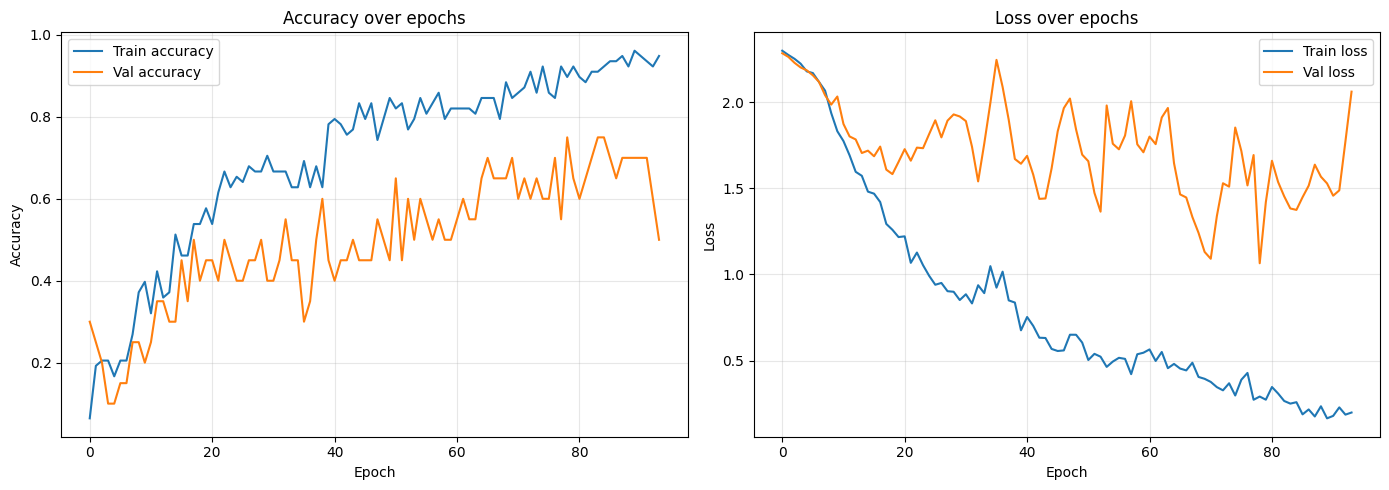

In [34]:
# Load training history from Drive (works in fresh sessions too)
history_path = os.path.join(PROJECT_ROOT, 'training_history.json')

if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history_data = json.load(f)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    axes[0].plot(history_data['accuracy'],     label='Train accuracy')
    axes[0].plot(history_data['val_accuracy'], label='Val accuracy')
    axes[0].set_title('Accuracy over epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss plot
    axes[1].plot(history_data['loss'],     label='Train loss')
    axes[1].plot(history_data['val_loss'], label='Val loss')
    axes[1].set_title('Loss over epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_ROOT, 'training_curves.png'), dpi=150)
    plt.show()
else:
    print('No training history found. Train the model first.')

In [36]:
# Generate predictions on the test set
y_pred_probs = model.predict(X_test, verbose=0)

# Convert one-hot test labels and predicted probabilities to integer class indices
y_true_int = np.argmax(y_test, axis=1)
y_pred_int = np.argmax(y_pred_probs, axis=1)

# Overall accuracy
accuracy = np.mean(y_true_int == y_pred_int)
print(f'Test accuracy: {accuracy:.2%}\n')

# Detailed per-class report: precision, recall, F1 score
# We explicitly pass labels=[0,1,2...9] via range(len(SIGNS))
# to handle cases where a class might be missing from the small test set.
print(classification_report(
    y_true_int,
    y_pred_int,
    labels=range(len(SIGNS)),
    target_names=SIGNS
))

Test accuracy: 75.00%

              precision    recall  f1-score   support

        book       1.00      1.00      1.00         1
       drink       1.00      1.00      1.00         3
    computer       0.67      0.67      0.67         3
      before       0.50      0.67      0.57         3
       chair       0.50      1.00      0.67         1
          go       1.00      0.33      0.50         3
     clothes       0.00      0.00      0.00         0
         who       0.67      1.00      0.80         2
       candy       1.00      0.50      0.67         2
      cousin       1.00      1.00      1.00         2

    accuracy                           0.75        20
   macro avg       0.73      0.72      0.69        20
weighted avg       0.82      0.75      0.74        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

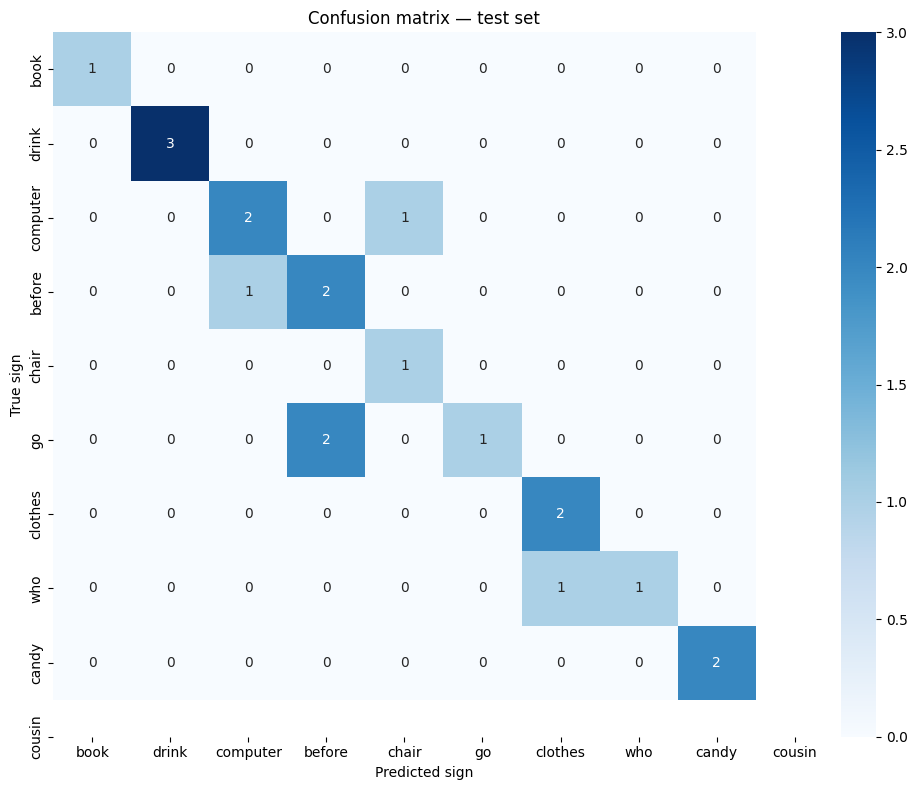

Confusion matrix saved to Drive.


In [37]:
# Confusion matrix visualization
cm = confusion_matrix(y_true_int, y_pred_int)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=SIGNS,
    yticklabels=SIGNS
)
plt.title('Confusion matrix — test set')
plt.ylabel('True sign')
plt.xlabel('Predicted sign')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'confusion_matrix.png'), dpi=150)
plt.show()

print('Confusion matrix saved to Drive.')

## Section 9 — Real-time demo with webcam and speech output

This is the full end-to-end demo. Here is the logic:

1. Capture frames from your webcam continuously
2. For each frame, extract MediaPipe landmarks
3. Accumulate frames into a rolling window of 30
4. Once the window is full, run a prediction
5. If the model is confident (above a threshold) and the prediction is different from the last spoken word, convert it to speech
6. Play the audio in the browser

**Confidence threshold:** The model always outputs a prediction, even when no hand is in frame. The threshold (0.85 by default) means we only act on predictions where the model is at least 85% confident. This prevents random noise from triggering false speech.

**Debouncing:** We track the last spoken word and only speak again if the prediction changes. This prevents the same word from being repeated 10 times in a row while you hold a sign.

In [38]:
def speak(text):
    """
    Converts a string to speech and plays it inside the Colab notebook.

    gTTS generates an MP3 file, which we encode as base64 and inject into
    an HTML audio element in the notebook. The audio plays automatically.

    Args:
        text: the word or phrase to speak
    """
    import io

    # Generate the MP3 audio in memory (no disk write needed)
    tts = gTTS(text=text, lang='en', slow=False)
    mp3_buffer = io.BytesIO()
    tts.write_to_fp(mp3_buffer)
    mp3_buffer.seek(0)

    # Encode as base64 so we can embed it in HTML
    audio_b64 = base64.b64encode(mp3_buffer.read()).decode('utf-8')

    # Inject an auto-playing audio element into the notebook output.
    # autoplay works in Colab notebooks.
    audio_html = f"""
    <audio autoplay>
        <source src="data:audio/mp3;base64,{audio_b64}" type="audio/mp3">
    </audio>
    """
    display(Javascript(f"""
        var audio = new Audio('data:audio/mp3;base64,{audio_b64}');
        audio.play();
    """))
    print(f'Spoke: "{text}"')


print('speak() function defined.')

speak() function defined.


In [53]:
# Load the model and label map from Drive.
# This cell works in a fresh session — no training needed.

model = load_model(os.path.join(MODEL_DIR, 'best_model.keras'))

with open(os.path.join(PROJECT_ROOT, 'label_map.json'), 'r') as f:
    label_map = json.load(f)

# Reverse the label map so we can go from index -> word
# label_map was: {'hello': 0, 'thanks': 1, ...}
# index_to_sign is: {0: 'hello', 1: 'thanks', ...}
index_to_sign = {v: k for k, v in label_map.items()}

print('Model and labels loaded from Drive.')
print(f'Recognizes: {list(index_to_sign.values())}')

Model and labels loaded from Drive.
Recognizes: ['book', 'drink', 'computer', 'before', 'chair', 'go', 'clothes', 'who', 'candy', 'cousin']


In [55]:
# Consolidated Real-time demo: Start webcam and Run loop in one place
from google.colab.output import eval_js

# 1. Ensure Webcam JS is active
eval_js(WEBCAM_JS)

CONFIDENCE_THRESHOLD = 0.85
DEMO_DURATION        = 60

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

window          = []
last_spoken     = None
start_time      = time.time()

print(f'Demo active for {DEMO_DURATION}s. Please sign clearly into the camera.')

with HandLandmarker.create_from_options(options) as landmarker:
    while time.time() - start_time < DEMO_DURATION:
        try:
            # Capture frame using the helper defined in the previous cell
            frame = get_frame_from_browser()

            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
            results = landmarker.detect(mp_image)
            landmarks = extract_landmarks(results)
            window.append(landmarks)

            if len(window) == SEQUENCE_LENGTH:
                input_sequence = np.expand_dims(np.array(window), axis=0)
                predictions = model.predict(input_sequence, verbose=0)[0]

                idx = np.argmax(predictions)
                conf = predictions[idx]
                word = index_to_sign[idx]

                print(f'Detected: {word} ({conf:.0%})', end='\r')

                if conf >= CONFIDENCE_THRESHOLD and word != last_spoken:
                    speak(word)
                    last_spoken = word

                window.pop(0)
        except Exception as e:
            # If the JS context fails, attempt to re-init once
            print("Connection to webcam lost. Re-initializing...")
            eval_js(WEBCAM_JS)
            time.sleep(1)

print('\nDemo complete.')

Demo active for 60s. Please sign clearly into the camera.


<IPython.core.display.Javascript object>

Spoke: "computer"


<IPython.core.display.Javascript object>

Spoke: "before"


<IPython.core.display.Javascript object>

Spoke: "go"

Demo complete.


In [56]:
# Force-stop all webcam streams by searching for all video elements
from google.colab.output import eval_js

eval_js("""
(async function() {
  // 1. Find all video elements on the page
  const videos = document.querySelectorAll('video');
  videos.forEach(video => {
    // 2. Stop all tracks associated with the video's stream
    if (video.srcObject) {
      const tracks = video.srcObject.getTracks();
      tracks.forEach(track => track.stop());
      video.srcObject = null;
    }
    // 3. Remove the video element from the UI
    video.remove();
  });

  // 4. Also check the global window object just in case
  if (window.stream) {
    window.stream.getTracks().forEach(track => track.stop());
    window.stream = null;
  }
  console.log('All webcam streams terminated.');
})();
""")
print('Webcam stopped.')

Webcam stopped.


## Section 10 — Migrating to PSL

When you are ready to replace ASL data with your own PSL signs:

1. Update the `SIGNS` list in Section 4 with your chosen PSL words.
   For example: `SIGNS = ['salam', 'shukriya', 'haan', 'nahi', 'paani', 'khaana', 'madad', 'naam', 'acha', 'bura']`

2. Delete the old data folder on Drive (`sign_language_project/data/`) and the old model (`sign_language_project/models/`).

3. Re-run from Section 4 (data collection) onwards. You will record your own PSL gestures.

4. Everything else in the notebook stays identical. The model architecture, training loop, evaluation code, and demo loop do not need any changes.

The key insight: this pipeline is language-agnostic. It learns whatever gesture-to-label mapping you teach it. ASL or PSL or any other sign system — the code does not know the difference.

---

## Files saved on your Google Drive

After a complete run, your Drive will contain:

| File | What it is |
|------|------------|
| `sign_language_project/data/` | All recorded landmark sequences |
| `sign_language_project/models/best_model.keras` | Trained model weights |
| `sign_language_project/labels.json` | List of sign names |
| `sign_language_project/label_map.json` | Name-to-index mapping |
| `sign_language_project/training_history.json` | Accuracy and loss per epoch |
| `sign_language_project/training_curves.png` | Plot of training progress |
| `sign_language_project/confusion_matrix.png` | Evaluation confusion matrix |

In a fresh Colab session, you only need to run:
- Section 1 (mount Drive)
- Section 2 (imports)
- Section 9 (load model + run demo)

Everything else is already saved.